**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Actividad: Clasificación con máquinas de vectores de soporte y árboles de decisión

## Objetivos

Mediante esta actividad se pretende que ponga en práctica la creación de modelos basados en máquinas de vectores de soporte y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Comprender el tratamiento de datos que hay que realizar para los modelos de clasificación.
- Entender y aplicar el algoritmo **Árboles de decisión** a un problema de clasificación.
- Entender y aplicar el algoritmo **Support Vector Machine** a un problema de clasificación.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

Este dataset ha sido generado para predecir el tipo de cubierta forestal únicamente a partir de variables cartográficas (sin datos de sensores remotos). El tipo de cubierta forestal real para una observación determinada (celda de 30 x 30 metros) se determinó a partir de los datos del Sistema de información de recursos (RIS) de la Región 2 del Servicio Forestal de EE. UU. (USFS). Las variables independientes se derivaron de datos obtenidos originalmente del Servicio Geológico de EE. UU. (USGS) y de datos del USFS. Los datos están en forma original (no escalados) y contienen columnas binarias (0 o 1) de datos para variables cualitativas independientes (áreas silvestres y tipos de suelo).
Para ampliar información sobre el dataset y su origen, recomendamos leer la descripción completa del dataset en el enlace del repositorio. l.

El objetivo de la clasificación será detectar el tipo de cubierta forestal.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Clasificación:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la **clasificación**.
    - Cómo utilizan las técnicas de **clasificación**, si realizan alguna adaptación de los algoritmos, esta deberá indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# se carga el dataset
#df = pd.read_csv('covtype.data', header=None) #adaptar a nuestra ruta
columnas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points',
    'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
    'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
    'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
    'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
    'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20',
    'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25',
    'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
    'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
    'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40',
    'Cover_Type'
]

df = pd.read_csv('covtype.data', header=None, names=columnas)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [3]:
## PON AQUÍ TU CÓDIGO
print(df.shape)

(581012, 55)


**RESPUESTA**

 El datatset tiene 581012 instancias y 55 columnas.

¿Cuántas variables continuas hay en el dataset?

In [ ]:
variables_continuas = [col for col in df.columns if df[col].nunique() > 2 and col != 'Cover_Type']
print(f"Variables continuas ({len(variables_continuas)}):")
print(variables_continuas)

Variables continuas (10):
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']


hay 10 variables continuas

¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

In [ ]:
variables_categoricas = [col for col in df.columns if df[col].nunique() == 2]
print(f"\nVariables categóricas binarias ({len(variables_categoricas)}):")
print(variables_categoricas)


Variables categóricas binarias (44):
['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40']


**hay** 44 variables categóricas

¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

Distribución de clases:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Porcentaje por clase:
Cover_Type
1    36.46
2    48.76
3     6.15
4     0.47
5     1.63
6     2.99
7     3.53
Name: count, dtype: float64


/tmp/ipykernel_998/1010981355.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cover_Type', data=df, palette='viridis')


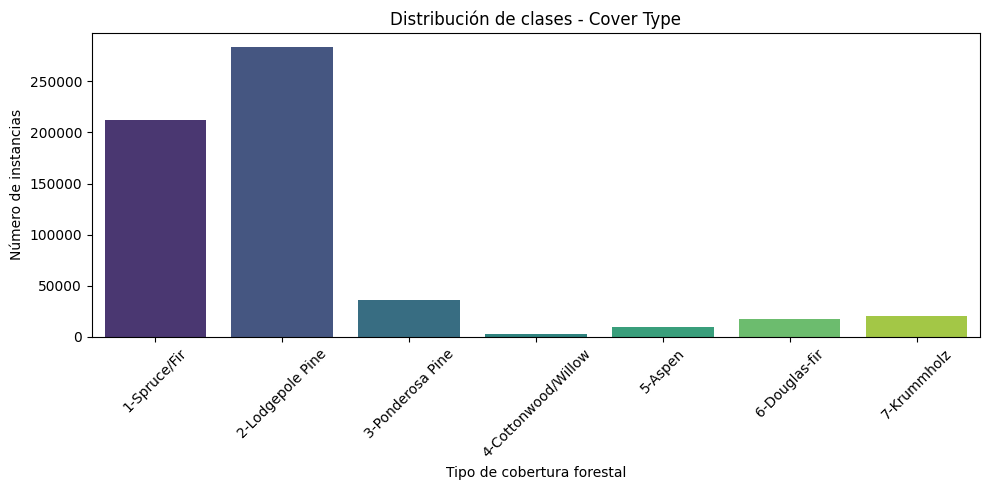

In [ ]:
## PON AQUÍ TU CÓDIGO
# Distribución de clases
distribucion = df['Cover_Type'].value_counts().sort_index()
print("Distribución de clases:")
print(distribucion)
print(f"\nPorcentaje por clase:")
print((distribucion / len(df) * 100).round(2))

# Visualización
plt.figure(figsize=(10, 5))
sns.countplot(x='Cover_Type', data=df, palette='viridis')
plt.title('Distribución de clases - Cover Type')
plt.xlabel('Tipo de cobertura forestal')
plt.ylabel('Número de instancias')
plt.xticks(ticks=range(7), labels=[
    '1-Spruce/Fir', '2-Lodgepole Pine', '3-Ponderosa Pine',
    '4-Cottonwood/Willow', '5-Aspen', '6-Douglas-fir', '7-Krummholz'
], rotation=45)
plt.tight_layout()
plt.show()

**Respuesta**

El dataset no está balanceado, ya que existen dos clases dominantes: Spruce/Fir con un 36,46% y Lodgepole Pine con un 48,76%. Solo con estas clases se suma el 85,22% de todas las instancias.

¿Existen valores nulos o perdidos en el dataset?

In [ ]:
## PON AQUÍ TU CÓDIGO
print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nTotal de valores nulos en el dataset: {df.isnull().sum().sum()}")

Valores nulos por columna:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11  

**Respuesta**

No existen valores nulos ni perdidos, todos los valores de las columnas estan completos.


¿Existe alguna variable altamente correlacionada con la variable de clase?

_Nota: Para responder a esto, como es muy difícil ver la matriz de correlaciones, recomendamos filtrar aquellas correlaciones superiores al 0.80 con la variable de clase.

Variables con correlación > 0.80 con Cover_Type:
Series([], Name: Cover_Type, dtype: float64)


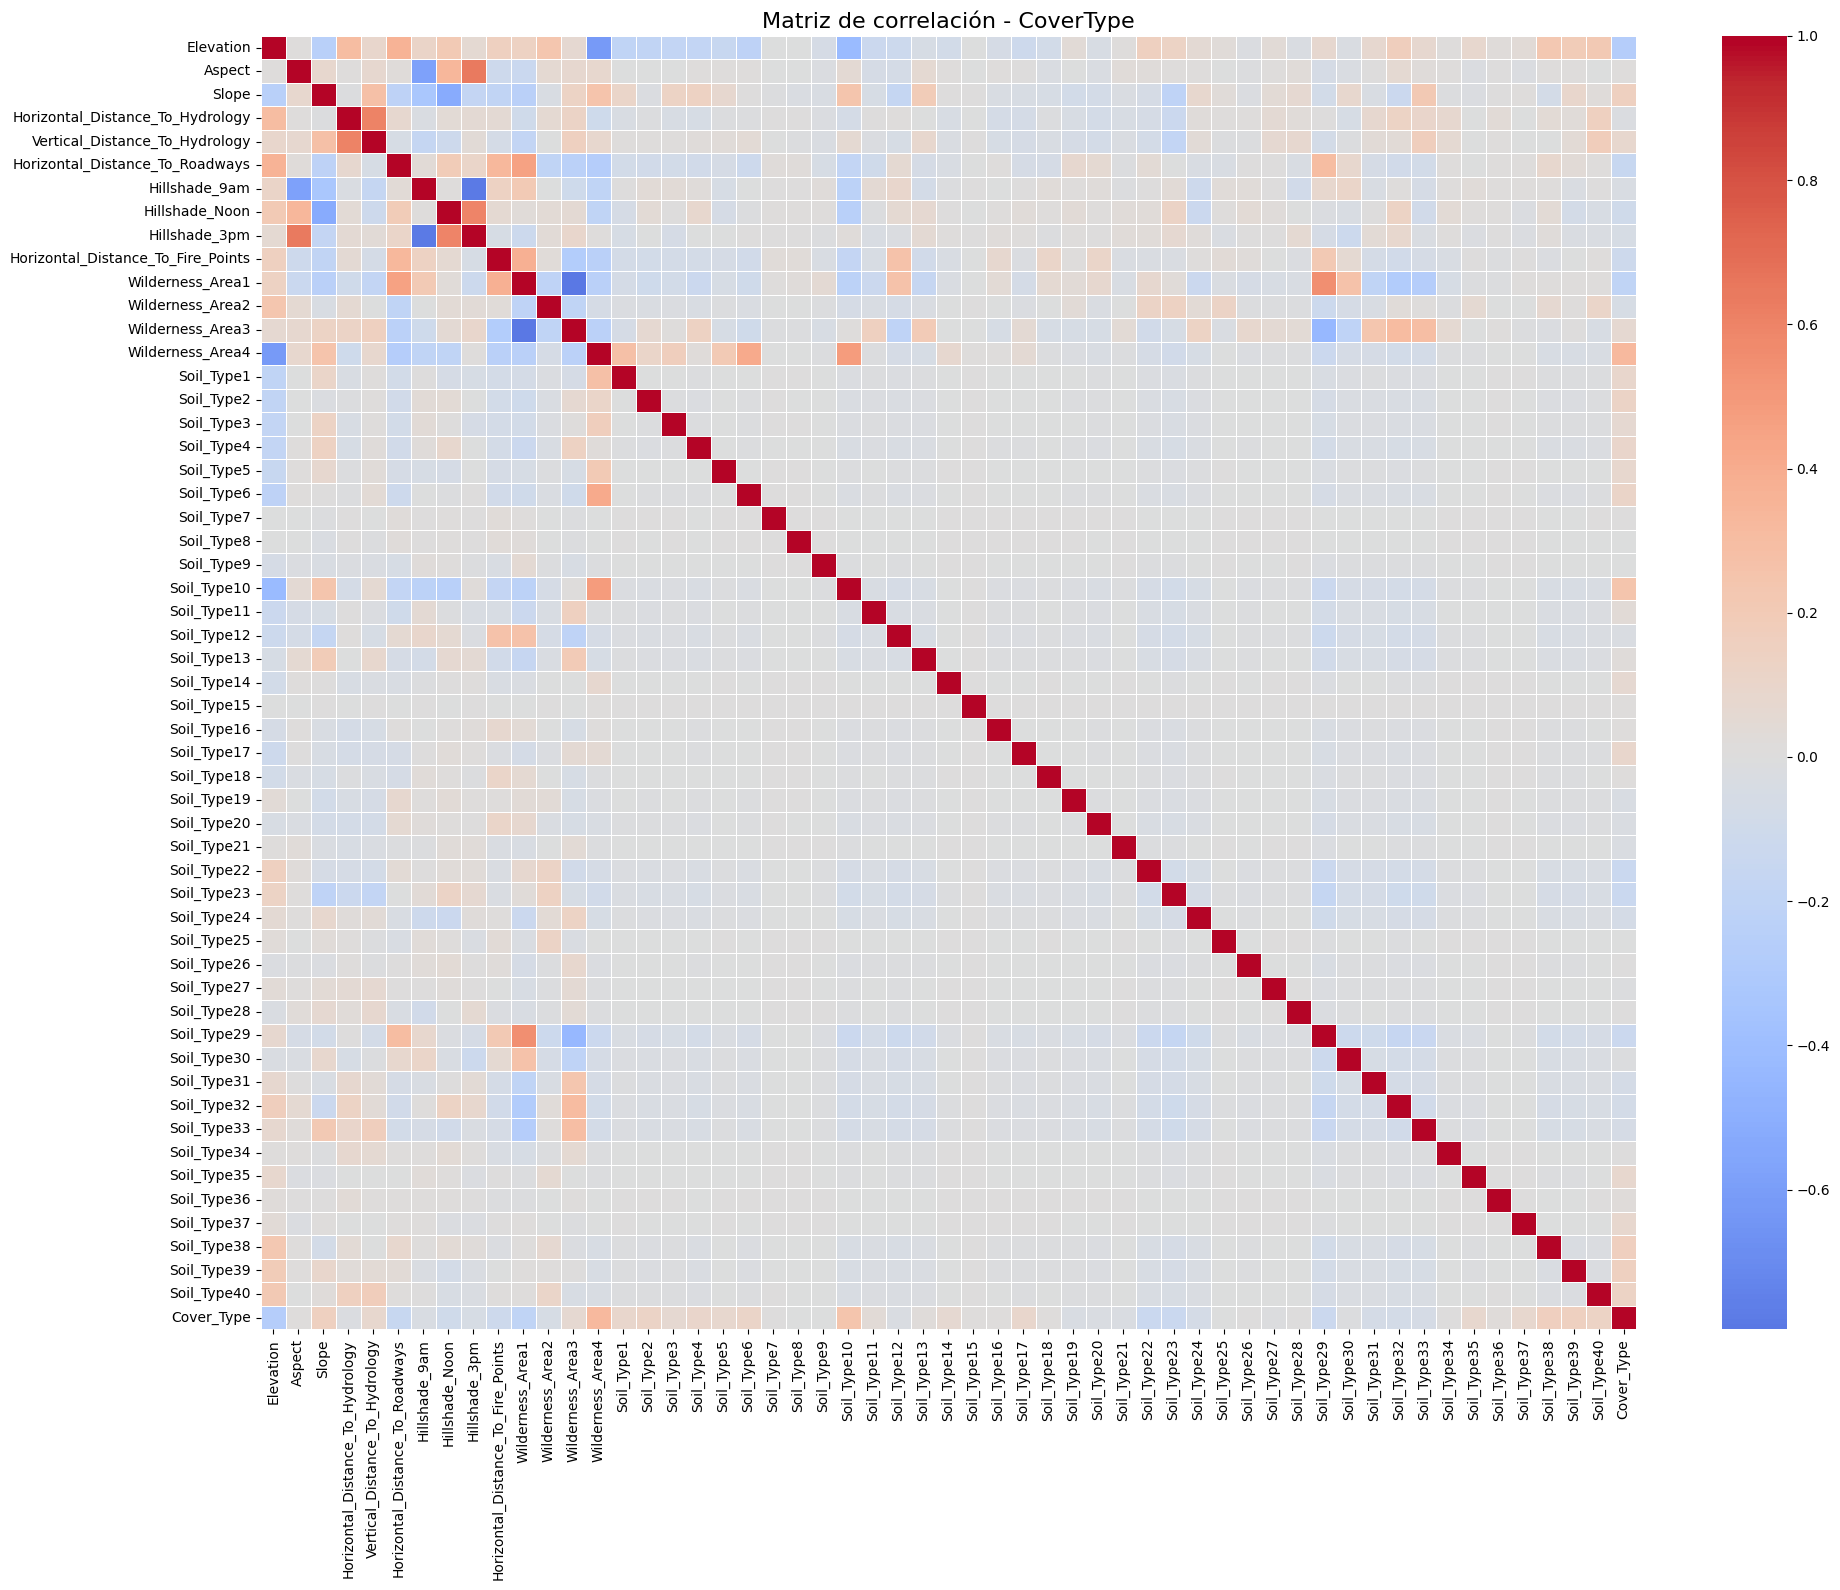

In [ ]:
## PON AQUÍ TU CÓDIGO
# Calculamos la correlación de todas las variables con Cover_Type
correlaciones = df.corr()['Cover_Type'].drop('Cover_Type')

# Filtramos las que superan 0.80 en valor absoluto
correlaciones_altas = correlaciones[abs(correlaciones) > 0.80]

print("Variables con correlación > 0.80 con Cover_Type:")
print(correlaciones_altas)

# Visualizamos todas las correlaciones con Cover_Type ordenadas
# Matriz de correlación completa con heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(
    df.corr(),
    annot=False,        # con 55 columnas los números no caben
    cmap='coolwarm',    # azul=correlación negativa, rojo=positiva
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlación - CoverType', fontsize=16)
plt.tight_layout()
plt.show()

**Resuesta**

Segun la grafica no existe ninguna variable altamente correlacionada con Cover_Type, ninguna supera el 0.80.

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? **Realiza dichas pruebas**.

/tmp/ipykernel_998/472099672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Elevation', data=df, palette='viridis')


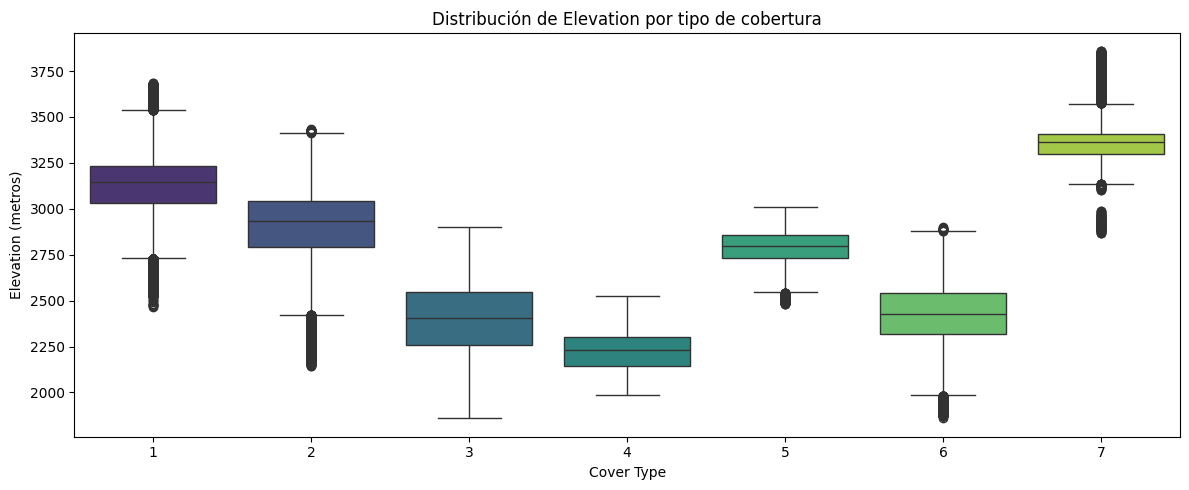

In [ ]:
# --- PRUEBA 1: Elevation por clase ---
plt.figure(figsize=(12, 5))
sns.boxplot(x='Cover_Type', y='Elevation', data=df, palette='viridis')
plt.title('Distribución de Elevation por tipo de cobertura')
plt.xlabel('Cover Type')
plt.ylabel('Elevation (metros)')
plt.tight_layout()
plt.show()

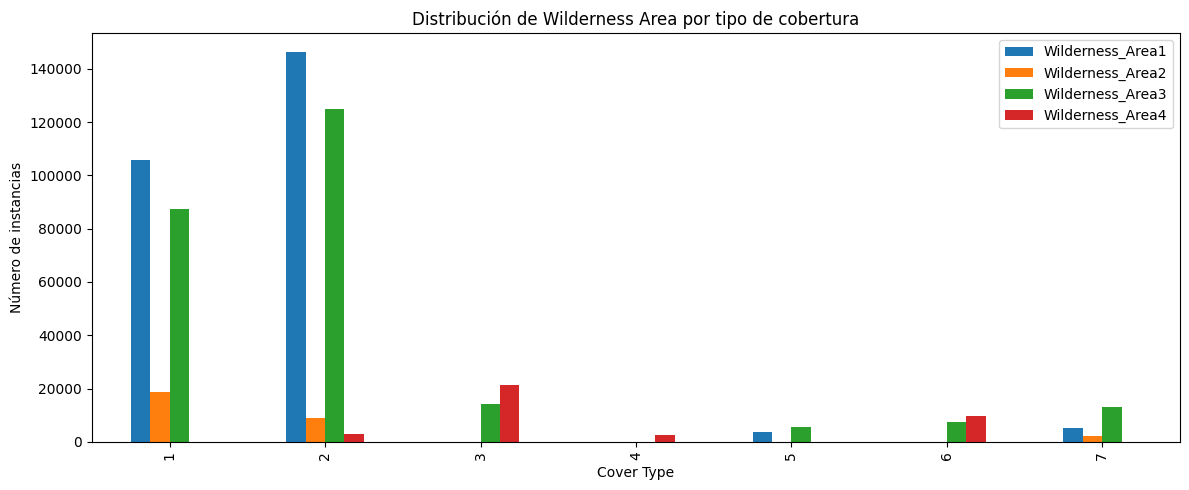

In [ ]:
# --- PRUEBA 2: Wilderness Area por clase ---
wilderness_cols = ['Wilderness_Area1','Wilderness_Area2','Wilderness_Area3','Wilderness_Area4']

# Sumamos cuántas instancias de cada clase están en cada área
wilderness_df = df.groupby('Cover_Type')[wilderness_cols].sum()

wilderness_df.plot(kind='bar', figsize=(12, 5))
plt.title('Distribución de Wilderness Area por tipo de cobertura')
plt.xlabel('Cover Type')
plt.ylabel('Número de instancias')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_998/3702864517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Horizontal_Distance_To_Roadways', data=df, palette='viridis')


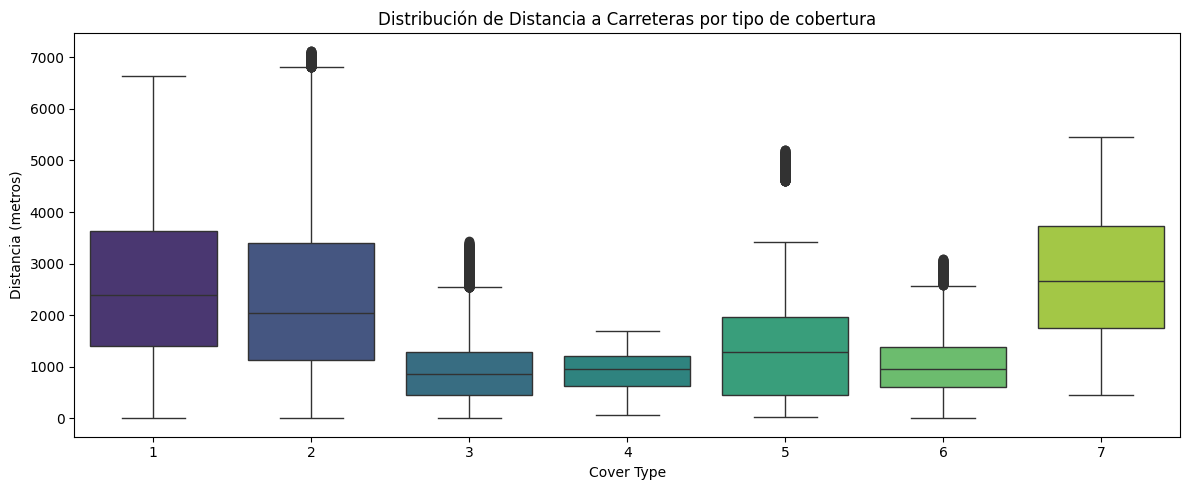

In [ ]:
# --- PRUEBA 3: Distancia a carreteras por clase ---
plt.figure(figsize=(12, 5))
sns.boxplot(x='Cover_Type', y='Horizontal_Distance_To_Roadways', data=df, palette='viridis')
plt.title('Distribución de Distancia a Carreteras por tipo de cobertura')
plt.xlabel('Cover Type')
plt.ylabel('Distancia (metros)')
plt.tight_layout()
plt.show()

**RESPUESTA**

Para las pruebas se usaron tres variables bastante influyentes.

Para validar las hipotesis se realizaron boxplots y graficos de barras por cada clase:

* **Elevation** esta variable es la que mejor separa los 7 tipos de bosque, esto seria porque cada tipo crece en altiuras diferentes. En el boxplot las cajas de cada clase esta en pocisiones distintas.

* **Wilderness_Area** segun la grafica separa bien las clases de acuerdo a las areas silvestres. Se puede observar que las clases 1 y 2 se distribuyen mas en las areas 1 y 3, en cambio las clase 3 aparece mas en el area 4.

* **Horizontal_Distance_To_Roadways** si muestra variacion entre las clases pero no es mucha, aun asi se puede observar que las clases 1, 2 y 7 tienden a estar más alejadas de carreteras que las clases 3, 4 y 6.



### Clasificación

In [ ]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)

**Árboles de decisión**

En esta parte de la actividad, hay que utilizar la librería https://scikit-learn.org/stable/modules/tree.html para resolver el problema de clasificación.

El algoritmo Decision Tree necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- max_depth
- min_samples_split
- min_samples_leaf
- max_features
- criterion
- ccp_alpha

**Indica qué son cada uno de estos hiperparámetros**

**RESPUESTA**

- **max_depth:** es la profundidad maxima del arbol, define cuantos niveles de divisiones puede hacer el arbol.
- **min_samples_split:** es el numero minimo de ejemplos o filas del dataset que debe tener un nodo para poder dividirse, si el nodo tiene menos ejemplos que este valor no se divide mas.
- **min_samples_leaf:** se usa para controlar que un nodo resultante de una division tenga suficientes filas o ejemplos.
- **max_features:** es el numero maximo de variables que el arbol evalua antes de cada division. Por ejemplo en este caso si se define el valor de 10, el arbol evaluara solo 10 de las 54 variables antes de dividir un nodo.
- **criterion:** es la formula matematica que usa el arbol para elegir la mejor pregunta para dividir en cada nodo. Ofrece dos opciones las cuales son Gini (mide impureza) y Entropy (mide ganancia de información).
- **ccp_alpha:** es el parametro de poda del arbol, se encarga de recortar las ramas que no aportan mucha informacion o poca precision. Por ejemplo si se definen valores altos se poda más el árbol, reduciendo su complejidad y evitando overfitting.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

**RESPUESTA**

Este permite asignar mayor peso a las clases minoritarias para el entrenamiento. Es muy útil cuando el dataset está desbalanceado como es este caso, en donde las clases 1 y 2 dominan con el 85% de los datos. Con class_weight='balanced' el modelo le da mas prioridad a las clases con pocas instancias como la clase 4 (Cottonwood/Willow).

Como primer paso para crear un clasificador con Árboles de Decision hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

**Respuesta**

No hace falta normalizar los datos para Árboles de Decisión porque este algoritmo toma decisiones comparando cada variable consigo misma mediante umbrales (por ejemplo ¿Elevation > 3000?), por lo que la escala de los valores no afecta el resultado. A diferencia de SVM o KNN,  los Árboles de Decisión no les importa si Elevation está en metros (3000) o normalizado (0.85), el resultado es el mismo

In [ ]:
## PON AQUÍ TU RESPUESTA Y/O CÓDIGO


Entrena un conjunto de modelos de árboles de decisión que utilicen todas las variables del dataset, con profundidades máximas de 5, 10, 20, 50 y 100 niveles.

El criterio para realizar las particiones debe ser Gini-index, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características evaluadas en cada partición deben ser todas.

In [ ]:
max_depth_values =

particion =
min_samples_split =
min_samples_leaf =
max_feature =

decisionTrees = [DecisionTreeClassifier(
        criterion=particion,
        max_depth=i,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_feature
    )    for i in max_depth_values]


In [4]:
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type', axis=1), df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.isnull().sum()} nulos")
print(f"y_test: {y_test.isnull().sum()} nulos")

X_train: (464809, 54)
X_test: (116203, 54)
y_train: 0 nulos
y_test: 0 nulos


In [5]:
# PON AQUÍ TU CÓDIGO PARA EL ENTRENAMIENTO
from sklearn.tree import DecisionTreeClassifier

# Valores de profundidad máxima
max_depth_values = [5, 10, 20, 50, 100]

# Hiperparámetros según el enunciado
particion = 'gini'        # criterio Gini-index
min_samples_split = 10    # mínimo de ejemplos para dividir un nodo
min_samples_leaf = 2      # mínimo de ejemplos para ser hoja
max_feature = None        # None = todas las variables

# Creamos un árbol por cada profundidad
decisionTrees = [DecisionTreeClassifier(
        criterion=particion,
        max_depth=i,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_feature
    ) for i in max_depth_values]

In [6]:
# Entrenamiento de todos los modelos
for tree in decisionTrees:
    tree.fit(X_train, y_train)

print("Modelos entrenados correctamente")

# Precisión de cada modelo en test
for i, tree in enumerate(decisionTrees):
    score = tree.score(X_test, y_test)
    print(f"max_depth={max_depth_values[i]} → precisión: {score:.4f}")

Modelos entrenados correctamente
max_depth=5 → precisión: 0.7024
max_depth=10 → precisión: 0.7778
max_depth=20 → precisión: 0.9030
max_depth=50 → precisión: 0.9331
max_depth=100 → precisión: 0.9331


Visualiza la matriz de confusión del modelo entrenado con 20 niveles.

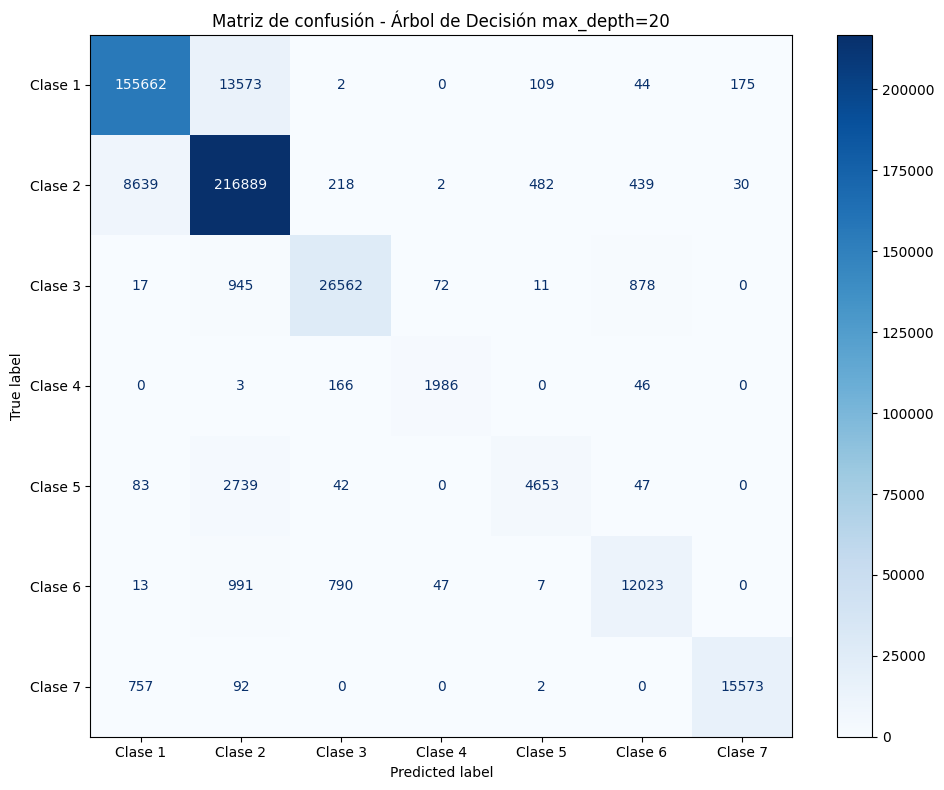

In [10]:
## PON AQUÍ TU CÓDIGO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionamos el modelo con max_depth=20 (índice 2)
modelo_20 = decisionTrees[2]

# Predicciones con los datos de entrenamiento
y_pred_20 = modelo_20.predict(X_train)

# Matriz de confusión
cm = confusion_matrix(y_train, y_pred_20)

# Visualización
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'Clase {i}' for i in range(1, 8)])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Matriz de confusión - Árbol de Decisión max_depth=20')
plt.tight_layout()
plt.show()

In [11]:
# Ejemplos correctamente clasificados por clase y total
correctos_por_clase = cm.diagonal()
total_por_clase = cm.sum(axis=1)

print("Ejemplos clasificados correctamente por clase:")
clases = ['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
          'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz']

for i, (clase, correctos, total) in enumerate(zip(clases, correctos_por_clase, total_por_clase)):
    print(f"Clase {i+1} ({clase}): {correctos} de {total} → {correctos/total*100:.2f}%")

print(f"\nTotal correctos: {correctos_por_clase.sum()} de {cm.sum()} → {correctos_por_clase.sum()/cm.sum()*100:.2f}%")

Ejemplos clasificados correctamente por clase:
Clase 1 (Spruce/Fir): 155662 de 169565 → 91.80%
Clase 2 (Lodgepole Pine): 216889 de 226699 → 95.67%
Clase 3 (Ponderosa Pine): 26562 de 28485 → 93.25%
Clase 4 (Cottonwood/Willow): 1986 de 2201 → 90.23%
Clase 5 (Aspen): 4653 de 7564 → 61.52%
Clase 6 (Douglas-fir): 12023 de 13871 → 86.68%
Clase 7 (Krummholz): 15573 de 16424 → 94.82%

Total correctos: 433348 de 464809 → 93.23%


¿Cuántos ejemplos ha clasificado correctamente?

**RESPUESTA**

El modelo con max_depth=20 clasificó correctamente 433.339 ejemplos de 464.809 en total (93.23%). La clase mejor clasificada fue la Clase 2 (Lodgepole Pine) con 95.67%, mientras que la peor es la Clase 5 (Aspen) con solo 61.55%, asi tambien se puede visualizar que esta se confunde frecuentemente con Lodgepole Pine (clase 2) por compartir condiciones geográficas similares.

Explica cómo funciona la clasificación **para cada una de las 7 clases**. ¿Hay alguna clase que clasifica mejor que otras?

> Add blockquote



**Respuesta**

A continuacion se explican los resultados del modelo con max_depth=20 para cada clase:

* Clase 1 (Spruce/Fir): 91.79% de acierto. Clasifico bien pero confunde algunos ejemplos con Clase 2 (13.583 ejemplos), esto puede ser porque ambas especies comparten rangos de altitud similares segun la variable Elevation.

* Clase 2 (Lodgepole Pine): 95.67% de acierto. Es la que mejor se clasifico, probablemente porque es la clase más representada del dataset (48.76% de los datos) esto le da al modelo muchos ejemplos para aprender.

* Clase 3 (Ponderosa Pine): 93.24% de acierto. Clasifica bien aunque confunde algunos ejemplos con Clase 2 (947) y Clase 6 (878), estas especies pueden tener condiciones geográficas similares (Wilderness_Area).

* Clase 4 (Cottonwood/Willow): 90.37% de acierto. A pesar que esta clase es la más minoritaria (0.47% del dataset) sus resultadis son muy buenos. Sus confusiones principales son con Clase 3 (164 ejemplos).

* Clase 5 (Aspen): 61.55% de acierto. Es la peor clasificada. El modelo confunde 2.736 ejemplos con Clase 2 (Lodgepole Pine), casi el 36% de sus ejemplos. Esto se debe a que Aspen comparte áreas y condiciones geográficas muy similares a Lodgepole Pine.

* Clase 6 (Douglas-fir): 86.66% de acierto. Tiene un rendimiento bueno aunque confunde muchos ejemplos con Clase 2 (990) y Clase 3 (792).

* Clase 7 (Krummholz): 94.87% de acierto. Clasifica bastante bien porque crece en altitudes muy altas (~3300m) segun la grafica del boxplot, esto hace que se la distingue mucho facil que el resto por la variable Elevation.

Finalmente se puede observar que la clase 2 (Lodgepole Pine) es la que mejor se clasifica con un 95.67% de acierto, esto porque es la mas representada con un 48.76% de los datos totales.

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

In [12]:
## PON AQUÍ TU CÓDIGO Y RESPUESTA
from sklearn.metrics import classification_report

# Comparamos todos los modelos en test
print("=== COMPARATIVA DE MODELOS EN TEST ===\n")
for i, tree in enumerate(decisionTrees):
    y_pred = tree.predict(X_test)
    print(f"--- max_depth={max_depth_values[i]} ---")
    print(classification_report(y_test, y_pred,
                                target_names=[f'Clase {i}' for i in range(1,8)]))

=== COMPARATIVA DE MODELOS EN TEST ===

--- max_depth=5 ---
              precision    recall  f1-score   support

     Clase 1       0.67      0.70      0.69     42275
     Clase 2       0.74      0.77      0.75     56602
     Clase 3       0.63      0.86      0.73      7269
     Clase 4       0.62      0.38      0.47       546
     Clase 5       0.55      0.06      0.11      1929
     Clase 6       0.72      0.03      0.05      3496
     Clase 7       0.71      0.45      0.55      4086

    accuracy                           0.70    116203
   macro avg       0.66      0.46      0.48    116203
weighted avg       0.70      0.70      0.69    116203

--- max_depth=10 ---
              precision    recall  f1-score   support

     Clase 1       0.77      0.76      0.77     42275
     Clase 2       0.79      0.84      0.81     56602
     Clase 3       0.72      0.85      0.78      7269
     Clase 4       0.81      0.68      0.74       546
     Clase 5       0.80      0.25      0.38      19

**Respuesta**

El modelo con max_depth=50 es el que obtuvo mejores resultados, aunque tiene resultados similares con max_depth=100, el de depth=50 seria mas simple y se evitaria el overfitting.

Los resultados por clase son:

* Las clases 2 y 7 son las que mejor se clasificaron con F1=0.94
* La clase 5 (Aspen) es la más difícil con F1=0.83, aunque mejora mucho respecto a depth=20 (0.67)
* La clase 4 (Cottonwood/Willow) también tienen una mejora notable con un F1=0.84

Con un macro avg F1=0.90 nos indica que el modelo clasifica bien todas las clases de manera equilibrada y no solo las mayoritarias.

Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

**Respuesta**

El mejor modelo fue el max_depth=50 esto porque:

* Mejor macro avg F1-score = 0.90 es equilibrado para todas las clases
* frente a depth=100 no mejora casi nada (0.00-0.01 de diferencia)
* Es más simple que depth=100, evita overfitting.
* Clasifica bien tanto clases mayoritarias (Clase 2: 0.94) como minoritarias (Clase 5: 0.83)

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
  
  **108424**

- ¿Cuántos ejemplos ha clasificado de manera errónea?

  **7779**

Total de ejemplos: **116203**  


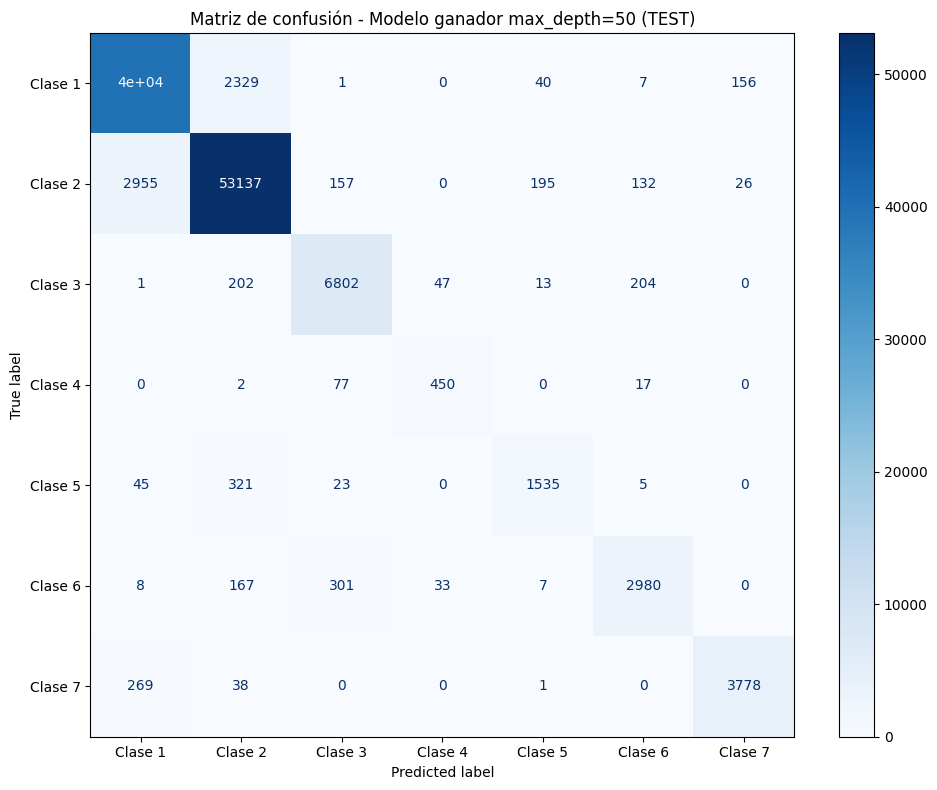

Correctamente clasificados: 108424 (93.31%)
Incorrectamente clasificados: 7779 (6.69%)
Total ejemplos: 116203


In [13]:
# Matriz de confusión del modelo ganador (max_depth=50) con datos de TEST
modelo_ganador = decisionTrees[3]  # índice 3 = max_depth=50

y_pred_ganador = modelo_ganador.predict(X_test)

cm_ganador = confusion_matrix(y_test, y_pred_ganador)

# Visualización
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ganador,
                               display_labels=[f'Clase {i}' for i in range(1, 8)])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Matriz de confusión - Modelo ganador max_depth=50 (TEST)')
plt.tight_layout()
plt.show()

# Ejemplos correctos e incorrectos
correctos = cm_ganador.diagonal().sum()
incorrectos = cm_ganador.sum() - correctos
total = cm_ganador.sum()

print(f"Correctamente clasificados: {correctos} ({correctos/total*100:.2f}%)")
print(f"Incorrectamente clasificados: {incorrectos} ({incorrectos/total*100:.2f}%)")
print(f"Total ejemplos: {total}")

Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

  El modelo no clasifica igual todas las clases.
  
  Tiene clases mejor clasificadas como las 1,2,3 y 7 con un F1-score entre 0.93 y 0.94, esto es porque son las clases con mas instancias en el dataset.

  Las clases mas dificiles de clasificar son las 4,5 y 6 con un F1-score entre 0.83 y 0.87, esto porque son las que menos instancias tienen en el dataset y tienden a confundirse con otras clases con caracteristicas similares.

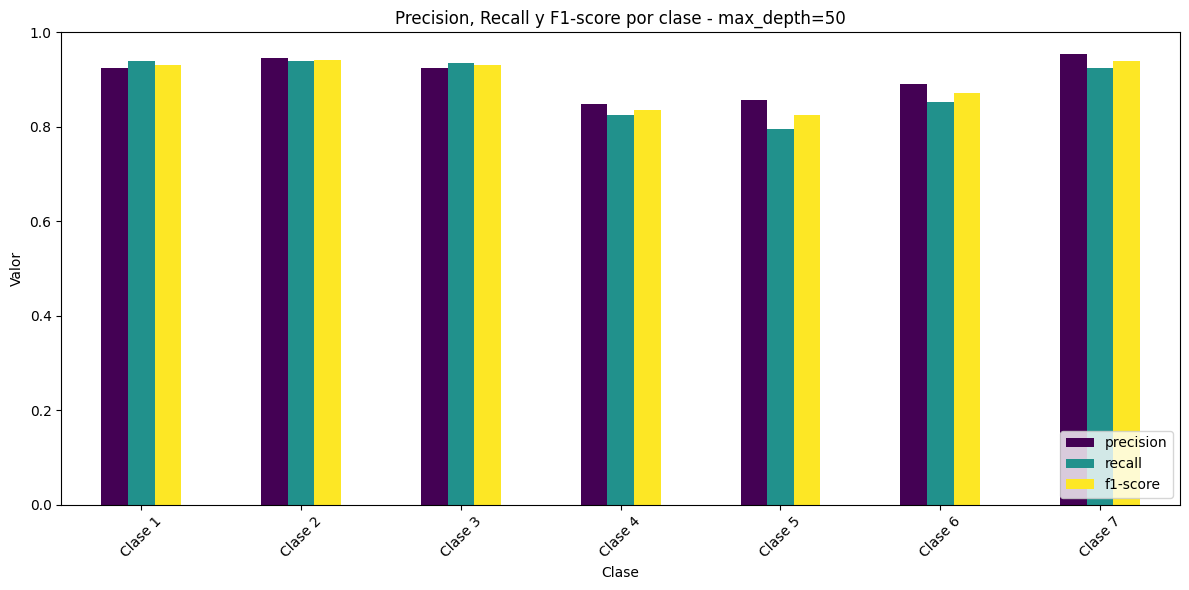

         precision    recall  f1-score
Clase 1   0.923803  0.940083  0.931872
Clase 2   0.945566  0.938783  0.942162
Clase 3   0.924059  0.935755  0.929870
Clase 4   0.849057  0.824176  0.836431
Clase 5   0.857063  0.795749  0.825269
Clase 6   0.890882  0.852403  0.871218
Clase 7   0.954040  0.924621  0.939100


In [14]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA
# Visualización de precision, recall y f1 por clase para el modelo ganador
from sklearn.metrics import classification_report
import pandas as pd

y_pred_ganador = decisionTrees[3].predict(X_test)

# Convertimos el report a dataframe para visualizarlo mejor
report = classification_report(y_test, y_pred_ganador,
                               target_names=[f'Clase {i}' for i in range(1, 8)],
                               output_dict=True)

df_report = pd.DataFrame(report).T.iloc[:7][['precision', 'recall', 'f1-score']]

# Gráfico
df_report.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Precision, Recall y F1-score por clase - max_depth=50')
plt.xlabel('Clase')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(df_report)

**Support Vector Machine**

In [3]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

**Indica qué son cada uno de estos hiperparámetros**

**RESPUESTA**

* **C:** Es el parámetro de regularización que controla cuántos errores le permite cometer al modelo durante el entrenamiento.
  * C pequeño (ej: 0.1): margen amplio, acepta más errores es un modelo más simple, puede tener tener underfit.
  * C grande (ej: 1000): margen estrecho, intenta no cometer errores es un modelo más complejo, puede tener overfit

* **kernel:** es la función matemática que usa SVM para separar las clases, tiene las siguientes opciones principales:

  * linear: separa con una línea recta
  * rbf (radial): separa con curvas, útil cuando los datos no son linealmente separables
  * poly: separa con funciones polinómicas

* **degree:** este solo se usa cuando kernel='poly'. Indica el grado del polinomio, por ejemplo degree=3 usa una función cúbica para separar las clases.

* **gamma:**  Controla cuánto influye cada ejemplo en la separación.
  * gamma alto: cada ejemplo influye poco, tendria una frontera muy irregular y ocasionaria overfit
  * gamma bajo: cada ejemplo influye mucho, tendria una frontera más suave y ocasionaria underfit
  * gamma='scale': valor automático que se calcula según los datos, es lo mas recomendado.






Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

**RESPUESTA**

Este indica cómo SVM manejara la clasificación multiclase (en este caso con 7 clases), esto porque SVM originalmente solo separa dos clases:

* 'ovr' (One vs Rest): entrena 7 clasificadores, cada uno separa una clase del resto
* 'ovo' (One vs One): entrena un clasificador por cada par de clases (21 clasificadores)

Es útil porque permite adaptar SVM a problemas multiclase como este caso, ya que originalmente este es un algoritmo binario.



Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

In [18]:
df = df.head(100000)

**Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias nos deja un porcentaje similar de instancias de cada clase, esto es, nuestro dataset debe quedar balanceado. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.**

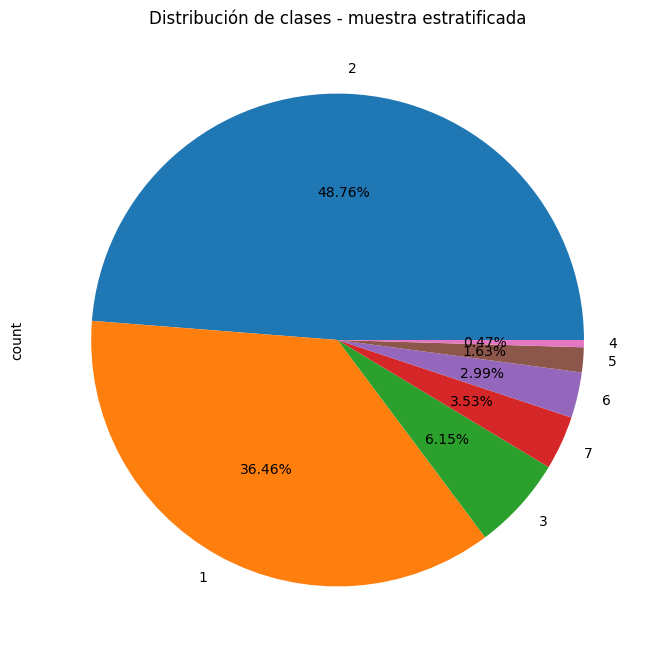

Cover_Type
2    48760
1    36460
3     6154
7     3530
6     2989
5     1634
4      473
Name: count, dtype: int64
Cover_Type
2    48.76
1    36.46
3     6.15
7     3.53
6     2.99
5     1.63
4     0.47
Name: count, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split

# Muestra estratificada - garantiza proporción similar de cada clase
df_svm, _ = train_test_split(df, train_size=100000,
                              stratify=df['Cover_Type'],
                              random_state=1)

# Comprobamos si efectivamente tenemos un número similar de instancias para cada clase
df_svm['Cover_Type'].value_counts().plot(kind='pie', autopct='%.2f%%', figsize=(8,8))
plt.title('Distribución de clases - muestra estratificada')
plt.show()

print(df_svm['Cover_Type'].value_counts())
print((df_svm['Cover_Type'].value_counts() / len(df_svm) * 100).round(2))

In [5]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split
X, y = df_svm.drop('Cover_Type', axis=1), df_svm['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos? Justifica tu respuesta.

**Respuesta**

Sí es necesario normalizar los datos para SVM porque a diferencia de los Árboles de Decisión, SVM calcula distancias entre ejemplos, por lo que variables con valores grandes como Elevation (\~3000m) dominarían completamente sobre variables pequeñas como Slope (\~15°). Usando StandardScaler todas las variables quedan con media=0 y desviación estándar≈1, esto equilibra equilibrada al modelo.


In [6]:
## PON AQUÍ TU CÓDIGO SI CONSIDERAS QUE HAY QUE NORMALIZAR LOS DATOS

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos normalizados correctamente")
print(f"Media de X_train_scaled: {X_train_scaled.mean().round(4)}")
print(f"Std de X_train_scaled: {X_train_scaled.std().round(4)}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Datos normalizados correctamente
Media de X_train_scaled: 0.0
Std de X_train_scaled: 0.9907
X_train: (80000, 54)
X_test: (20000, 54)


Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes. Utiliza kernel radial, y gamma con valor *scale*.

In [8]:
from sklearn.svm import SVC
import joblib
import time

C_values = [0.1, 1, 10, 100, 1000]
svc = []

for c in C_values:
    print(f"Entrenando C={c}...")
    inicio = time.time()

    modelo = SVC(C=c, kernel='rbf', gamma='scale')
    modelo.fit(X_train_scaled, y_train)

    # Guardamos en el ambiente de Colab
    joblib.dump(modelo, f'svc_C{c}.pkl')

    fin = time.time()
    score = modelo.score(X_test_scaled, y_test)
    svc.append(modelo)
    print(f"C={c} → precisión: {score:.4f} | tiempo: {fin-inicio:.1f}s guardado")

Entrenando C=0.1...
C=0.1 → precisión: 0.7397 | tiempo: 394.4s guardado
Entrenando C=1...
C=1 → precisión: 0.7704 | tiempo: 329.0s guardado
Entrenando C=10...
C=10 → precisión: 0.8018 | tiempo: 343.0s guardado
Entrenando C=100...
C=100 → precisión: 0.8305 | tiempo: 664.5s guardado
Entrenando C=1000...
C=1000 → precisión: 0.8501 | tiempo: 2501.6s guardado


In [ ]:
### PON AQUÍ TU CÓDIGO

In [ ]:
score

Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

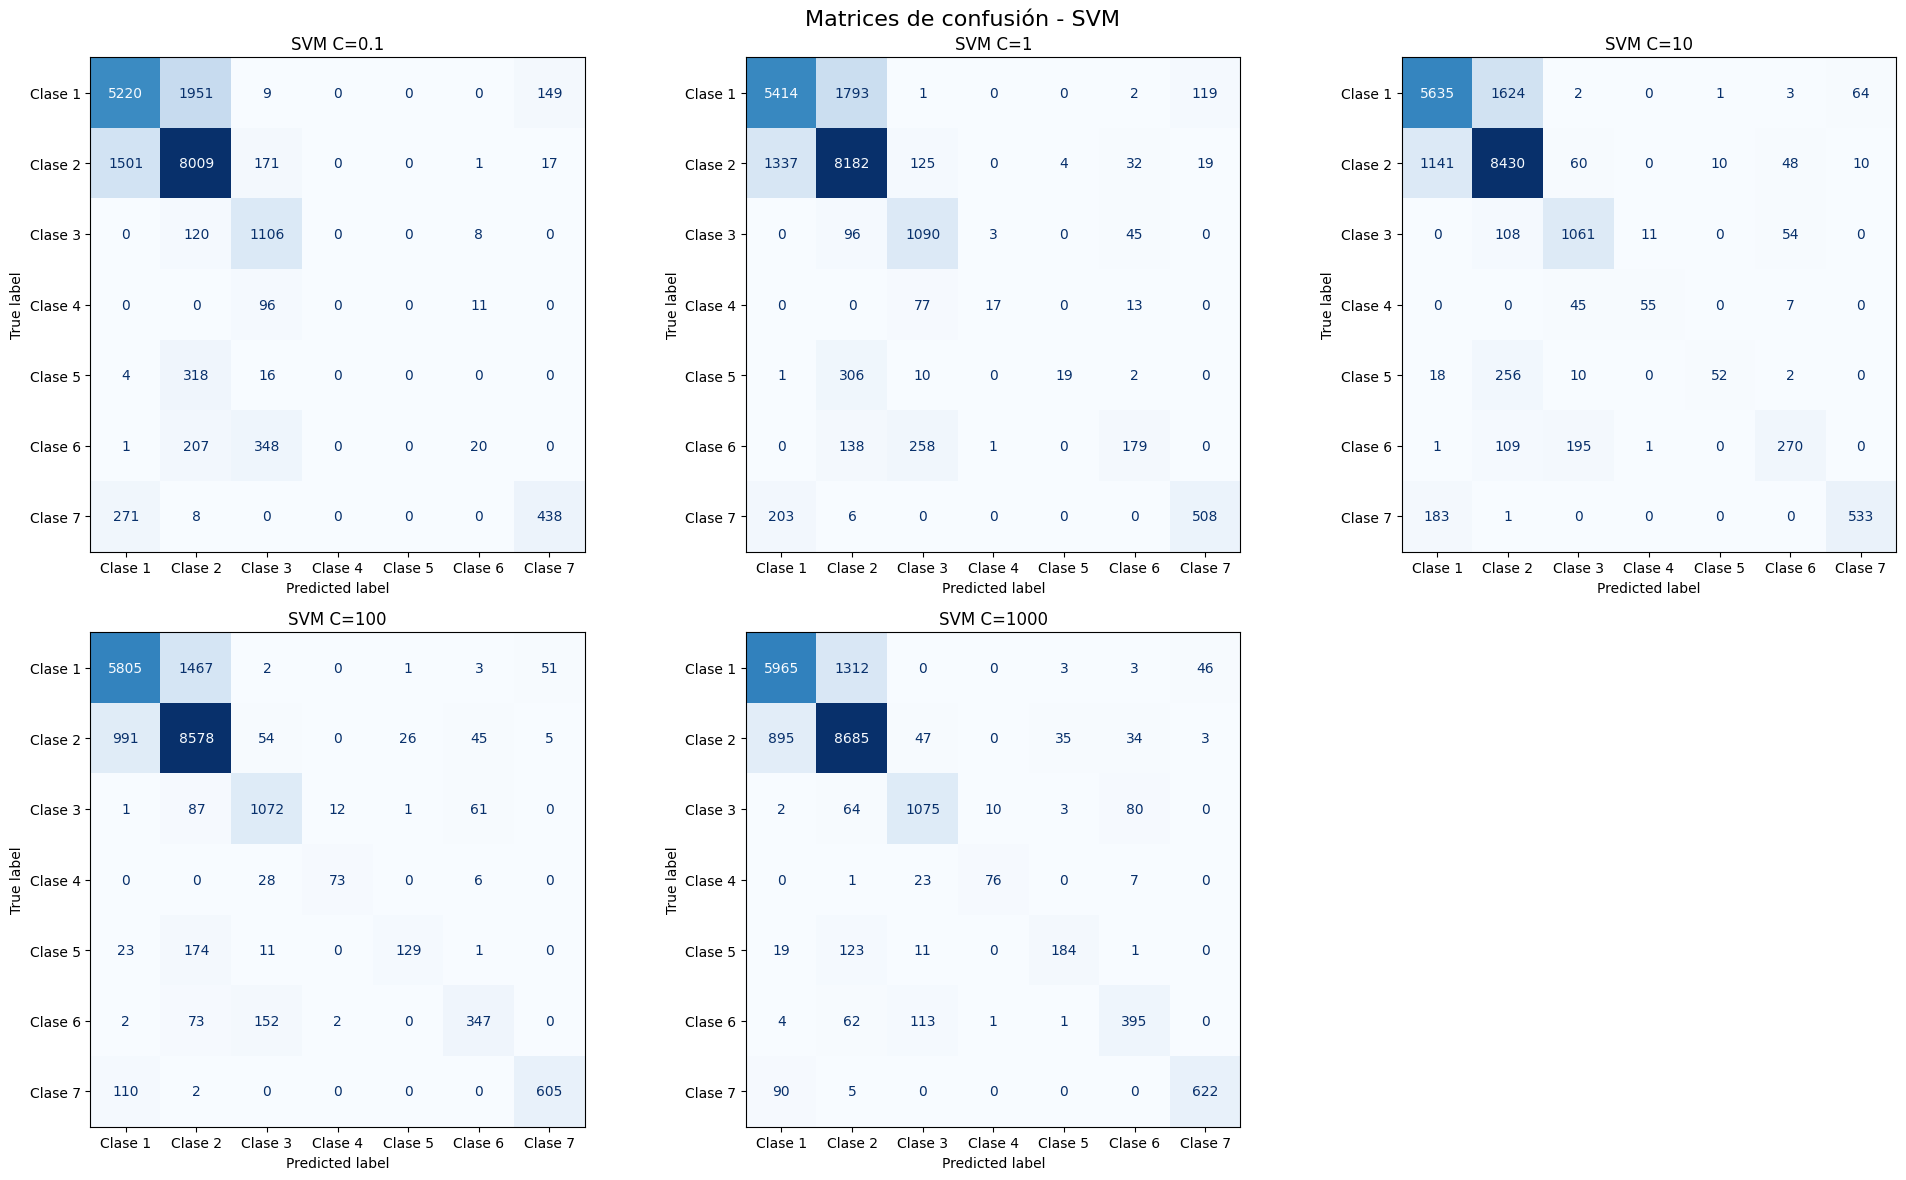

In [9]:
## PON AQUÍ TU CÓDIGO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, modelo in enumerate(svc):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=[f'Clase {j}' for j in range(1, 8)])
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f'SVM C={C_values[i]}')

# Ocultamos el subplot sobrante
axes[5].set_visible(False)

plt.suptitle('Matrices de confusión - SVM', fontsize=16)
plt.tight_layout()
plt.show()

¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

In [10]:
# Ejemplos correctos e incorrectos por modelo
print("=== RESULTADOS POR MODELO ===\n")
for i, modelo in enumerate(svc):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    correctos = cm.diagonal().sum()
    incorrectos = cm.sum() - correctos
    total = cm.sum()

    print(f"C={C_values[i]}:")
    print(f"  Correctos:   {correctos} ({correctos/total*100:.2f}%)")
    print(f"  Incorrectos: {incorrectos} ({incorrectos/total*100:.2f}%)")
    print()

=== RESULTADOS POR MODELO ===

C=0.1:
  Correctos:   14793 (73.97%)
  Incorrectos: 5207 (26.04%)

C=1:
  Correctos:   15409 (77.05%)
  Incorrectos: 4591 (22.96%)

C=10:
  Correctos:   16036 (80.18%)
  Incorrectos: 3964 (19.82%)

C=100:
  Correctos:   16609 (83.05%)
  Incorrectos: 3391 (16.96%)

C=1000:
  Correctos:   17002 (85.01%)
  Incorrectos: 2998 (14.99%)



**RESPUESTA**

Los modelos SVM clasificaron correctamente los siguientes ejemplos sobre un total de 20.000:

* C=0.1 → 14.793 correctos (73.97%) / 5.207 incorrectos (26.04%)
* C=1 → 15.409 correctos (77.05%) / 4.591 incorrectos (22.96%)
* C=10 → 16.036 correctos (80.18%) / 3.964 incorrectos (19.82%)
* C=100 → 16.609 correctos (83.05%) / 3.391 incorrectos (16.96%)
* C=1000 → 17.002 correctos (85.01%) / 2.998 incorrectos (14.99%)

A mayor valor de C mayor precisión, aunque el tiempo de entrenamiento crece enormemente. El modelo con C=1000 es el que mejor clasifica con un 85.01% de acierto.

Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

In [12]:
## PON AQUÍ TU CÓDIGO
# Modelo ganador C=1000 (índice 4)
modelo_ganador_svm = svc[4]

# Predicciones con datos de test
y_pred_svm = modelo_ganador_svm.predict(X_test_scaled)
print("Predicciones realizadas")

Predicciones realizadas


Visualiza la matriz de confusión de los datos de test para este modelo ganador.
- ¿Cuántos ejemplos ha clasificado bien el modelo?

  **17002**

- ¿Cuántos ejemplos ha clasificado de manera errónea?

  **2998**

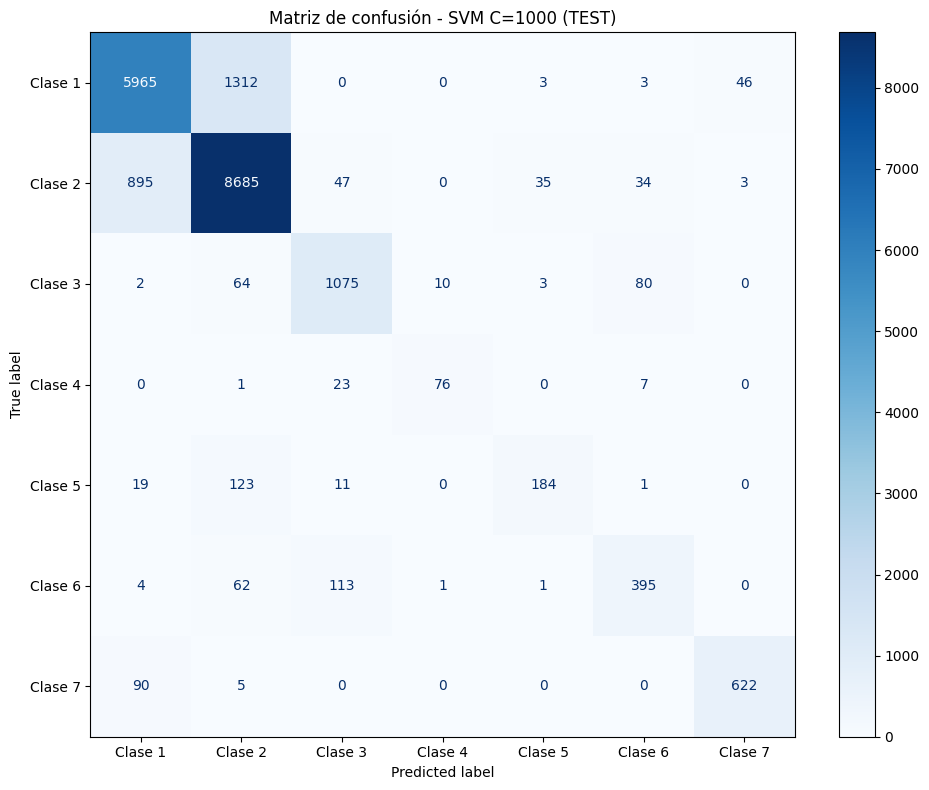

Correctamente clasificados:   17002 (85.01%)
Incorrectamente clasificados: 2998 (14.99%)


In [14]:
# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                               display_labels=[f'Clase {i}' for i in range(1, 8)])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Matriz de confusión - SVM C=1000 (TEST)')
plt.tight_layout()
plt.show()

# Correctos e incorrectos
correctos = cm_svm.diagonal().sum()
incorrectos = cm_svm.sum() - correctos
total = cm_svm.sum()

print(f"Correctamente clasificados:   {correctos} ({correctos/total*100:.2f}%)")
print(f"Incorrectamente clasificados: {incorrectos} ({incorrectos/total*100:.2f}%)")

Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

**Respuesta**

El modelo SVM con C=1000 no clasifica igual todas las clases:

* Clase 7 (Krummholz) es la mejor clasificada con F1=0.896, gracias a su altitud característica que la hace muy distinguible del resto.
* Clases 2 y 3 también tienen buen rendimiento con F1 de 0.871 y 0.859 respectivamente.
* Clase 5 (Aspen) es la peor clasificada con F1=0.652 y un recall muy bajo de 0.544, lo que significa que el modelo solo encuentra el 54% de los ejemplos reales de Aspen, confundiéndolos frecuentemente con otras clases.
* Clase 6 (Douglas-fir) también tiene dificultades con F1=0.721.

En general las clases minoritarias (4, 5 y 6) son las más difíciles de clasificar, igual que ocurrió con los Árboles de Decisión.

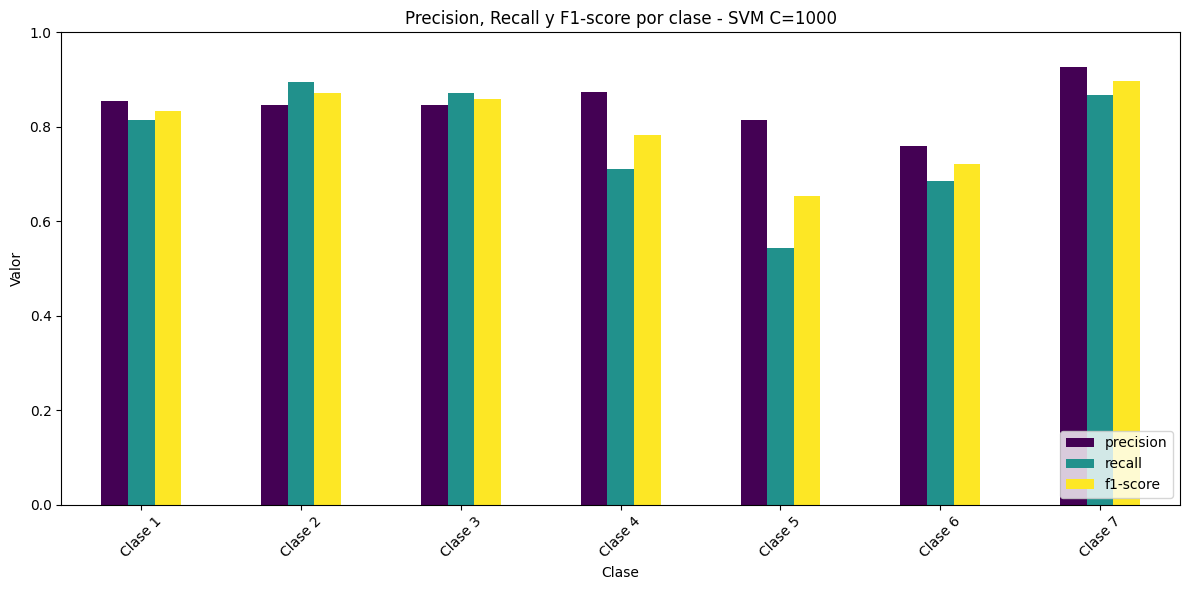

         precision    recall  f1-score
Clase 1   0.855197  0.813890  0.834032
Clase 2   0.847152  0.895453  0.870633
Clase 3   0.847124  0.871151  0.858969
Clase 4   0.873563  0.710280  0.783505
Clase 5   0.814159  0.544379  0.652482
Clase 6   0.759615  0.685764  0.720803
Clase 7   0.926975  0.867503  0.896254


In [15]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA
from sklearn.metrics import classification_report

# Classification report del modelo ganador SVM C=1000
report_svm = classification_report(y_test, y_pred_svm,
                               target_names=[f'Clase {i}' for i in range(1, 8)],
                               output_dict=True)

df_report_svm = pd.DataFrame(report_svm).T.iloc[:7][['precision', 'recall', 'f1-score']]

# Gráfico
df_report_svm.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Precision, Recall y F1-score por clase - SVM C=1000')
plt.xlabel('Clase')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(df_report_svm)

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

**Respuesta**

El modelo que obtiene mejores resultados de clasificación es el Árbol de Decisión con max_depth=50, con una precisión del 93.26% frente al 85.01% del mejor modelo SVM (C=1000).

Los experimentos se realizaron en Google Colab con el entorno estándar gratuito, que dispone de un procesador Intel Xeon con 2 vCPUs y 13GB de RAM. Bajo estas condiciones, el Árbol de Decisión entrenó con el dataset completo de 581.012 instancias en segundos, mientras que SVM requirió reducir el dataset a 100.000 instancias y tardó más de 40 minutos para el modelo con C=1000.

Por tanto el Árbol de Decisión es superior tanto en rendimiento como en eficiencia computacional para este problema.

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **clasificación** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la clasificación. **Técnicas de clasificación** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.